# Customer Segmentation using K-Means Clustering

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


## Step 2: Load the Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Step 3: Display the Dataset

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 4: Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Step 5: Statistical Summary

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Step 6: Check Missing Values

In [6]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Step 7: Check Duplicate Values

In [7]:
df.duplicated().sum()

np.int64(0)

## Step 8: Remove Duplicate Values

In [8]:
df = df.drop_duplicates()

print("Duplicate values removed successfully!")

Duplicate values removed successfully!


## Step 9: Gender Distribution (Bar Chart)

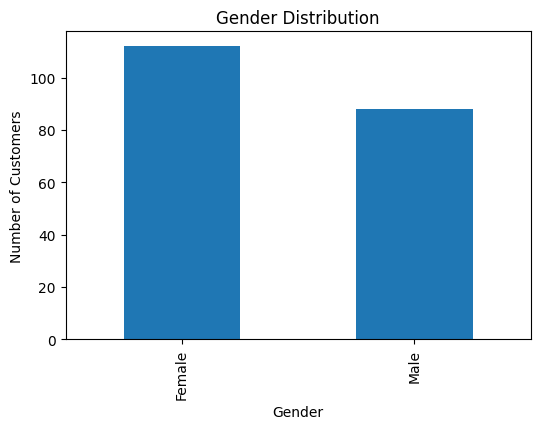

In [10]:
plt.figure(figsize=(6,4))

df['Genre'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## Step 10: Age Distribution (Histogram)

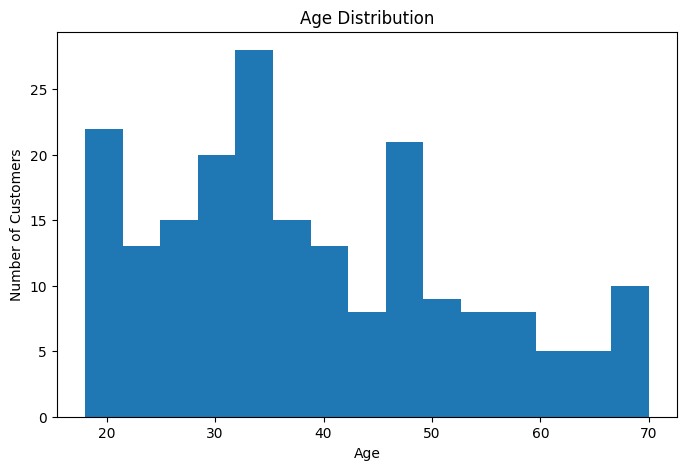

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

## Step 11: Annual Income Distribution

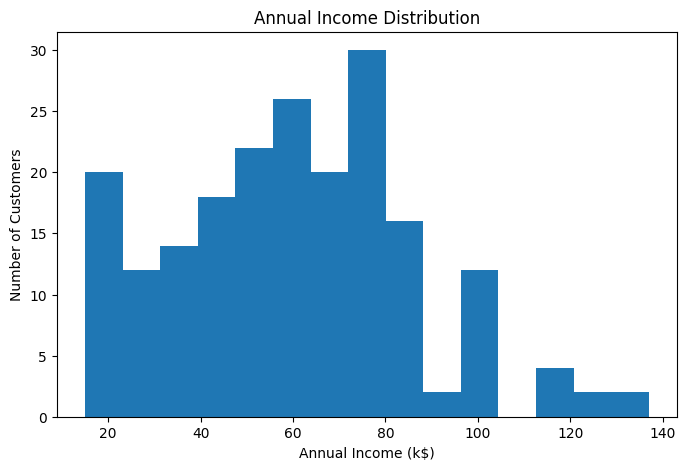

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['Annual Income (k$)'], bins=15)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

## Step 12: Spending Score Distribution

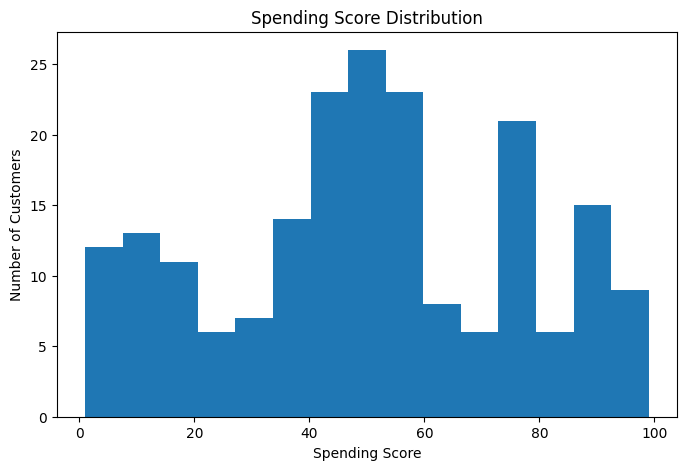

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df['Spending Score (1-100)'], bins=15)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

## Step 13: Encode Gender

In [15]:
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

print("Gender Encoded Successfully!")

Gender Encoded Successfully!


## Step 14: Correlation Heatmap

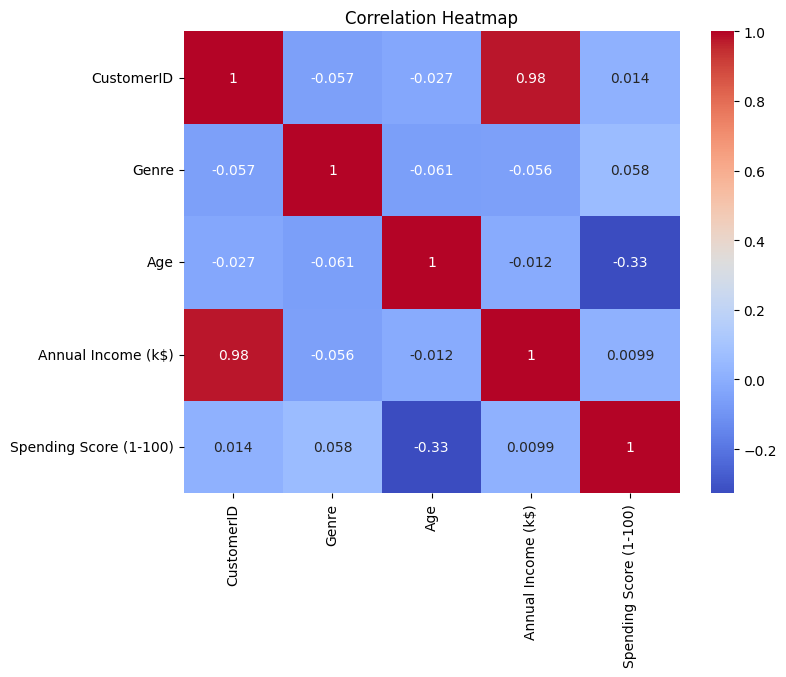

In [16]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## Step 15: Select Features for Clustering

In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Step 16: Find the Optimal Number of Clusters (Elbow Method)

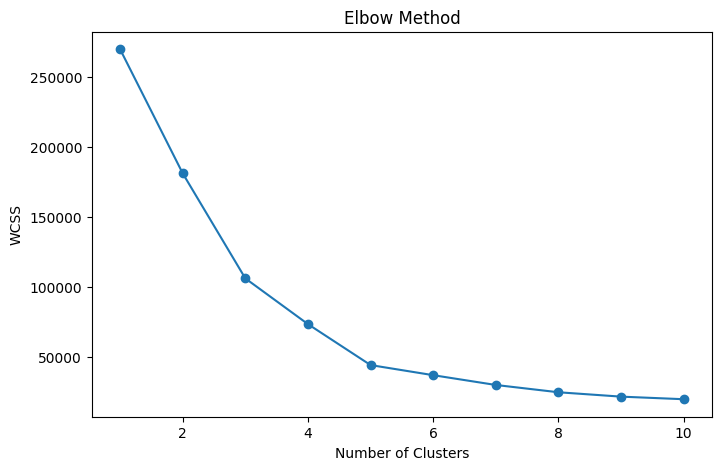

In [18]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

## Step 17: Train K-Means Model

In [19]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

y_kmeans = kmeans.fit_predict(X)

print("Model Trained Successfully!")

Model Trained Successfully!


## Step 18: Display Cluster Labels

In [20]:
print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


## Step 19: Customer Segmentation Visualization

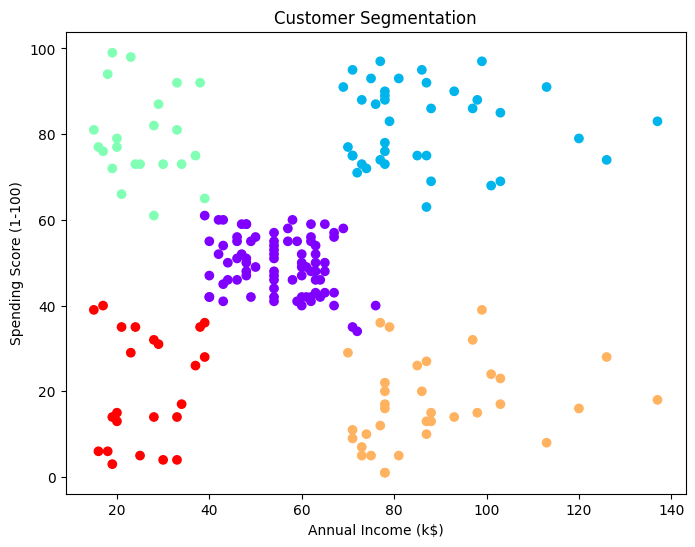

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    cmap='rainbow'
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

## Step 20: Display Cluster Centers

In [22]:
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


## Step 21: Add Cluster Labels to Dataset

In [24]:
df['Cluster'] = y_kmeans

print("Cluster labels added successfully!")

Cluster labels added successfully!


## Step 22: Display Final Dataset

In [25]:
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,0,19,15,39,4
1,2,0,21,15,81,2
2,3,1,20,16,6,4
3,4,1,23,16,77,2
4,5,1,31,17,40,4
5,6,1,22,17,76,2
6,7,1,35,18,6,4
7,8,1,23,18,94,2
8,9,0,64,19,3,4
9,10,1,30,19,72,2


## Step 23: Number of Customers in Each Cluster

In [26]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


## Step 24: Project Conclusion

### Conclusion

This project successfully segmented customers into different groups using the K-Means Clustering algorithm. The dataset was cleaned, analyzed, and visualized using different charts. The Elbow Method was used to determine the optimal number of clusters, and customers were grouped based on their Annual Income and Spending Score. These customer segments can help businesses improve marketing strategies and customer targeting.